<a href="https://colab.research.google.com/github/pumazzo/ML-ISS2026/blob/main/DL_basics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basi del Deep Learning: Esercitazione

**Corso:** *Introduzione al Machine Learning per le Scienze della Salute* (ISS, 2026)  
**Docente:** Andrea Cacioppo  
**Data:** 17 giugno 2026

---

## Obiettivo della sessione

Costruire, addestrare e capire una rete neurale **da zero in PyTorch**:

✍️ **Come funziona questo notebook.** Alcune celle di codice sono **da completare**:
blocchi `# TODO` e i `...` da sostituire. La teoria e le funzioni di supporto (grafici,
caricamento dati) sono già pronte. Non è importante soffermarci sui dettagli di Python, ma capire come funziona PyTorch e come costruire una rete neurale.

---
## ⚙️ Prima di iniziare: aprire il notebook su Google Colab

1. Vai su [colab.research.google.com](https://colab.research.google.com) e apri questo file: **File → Upload notebook**.
2. **Attiva la GPU:** menu **Runtime → Change runtime type → T4 GPU → Save**.


---
## 0 · Setup

Carichiamo le librerie, fissiamo un seed per la riproducibilità, e selezioniamo il device (cioè CPU o GPU).

In [ ]:
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# --- Riproducibilita' ----------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Device --------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')


PyTorch 2.12.0  |  device: mps


---
## 🎯 Scaletta e obiettivi

Costruire una **rete neurale da zero** in PyTorch.

Partiamo da un problema molto semplice: la classificazione di due gruppi di punti su un
piano appartenenti a una distribuzione semplice. Ogni punto ha **due feature**, $\mathbf{x}=(x_1,x_2)\in\mathbb{R}^2$, e una sola etichetta
$y\in\{0,1\}$ (i due colori, blu e rosso).

![Anteprima del problema 2D make_moons](attachment:moons.png)

**NOTA: questa immagine non rappresenta un esempio, bensì l'intero dataset. Un singolo esempio è un punto, con le sue coordinate $x_1$ e $x_2$.**

Un **modello lineare** non basta (se avete capito cosa vuol dire lineare, è ovvio): un classificatore lineare separa il piano con una
*retta* (più in generale separa lo spazio con un iperpiano), decidendo in base al segno di $\mathbf{w}^\top\mathbf{x}+b$, mentre qui serve un confine
*curvo*. Una rete neurale costruisce una trasformazione non lineare, alternando mappe affini
e una **nonlinearità** $\sigma$:

$$f(\mathbf{x}) = W_2\,\sigma\!\big(W_1\mathbf{x}+\mathbf{b}_1\big)+\mathbf{b}_2 .$$

In questo caso è $\sigma$ a fare il lavoro, senza cui la composizione di due strati lineari collassa in un
*unico* strato lineare, $W_2 W_1\mathbf{x}+\text{cost.}$, e ricadremmo nella solita retta.

A questo punto passiamo a **immagini vere** (MNIST, cifre
scritte a mano), dove ogni esempio è $\mathbf{x}\in\mathbb{R}^{28\times 28}=\mathbb{R}^{784}$ e le
classi diventano dieci, $y\in\{0,1,\dots,9\}$.

![Anteprima di cifre MNIST](attachment:mnist.png)

**NOTA: in questo caso non possiamo visualizzare l'intero dataset in una immagine, perché ogni esempio ha 784 feature (i pixel) e non possiamo rappresentarle sul piano.**

Costruiamo la prima rete e il suo **training loop**: addestrare significa cercare i parametri
$\theta$ (pesi $W$ e bias $\mathbf{b}$) che minimizzano l'errore medio sul dataset,
$$\min_{\theta}\ \frac{1}{N}\sum_{i=1}^{N}\mathcal{L}\big(f_\theta(\mathbf{x}_i),\,y_i\big),$$
dove $\mathcal{L}$ è la funzione di perdita (loss) che misura l'errore di ogni previsione.

Miglioriamo poi l'allenamento usando attivazioni migliori (ReLU e il problema del *vanishing gradient*),
ottimizzatori migliori (da SGD ad Adam), difese contro l'**overfitting** (dropout, weight decay),
fino alle **CNN**, che sfruttano un **bias induttivo** per migliorare le performance sulle immagini.

---
## 1 · Dataset delle mezze lune: perché serve la non linearità

Cominciamo dal problema **più semplice possibile**: un dataset giocattolo 2D che possiamo
visualizzare per intero.

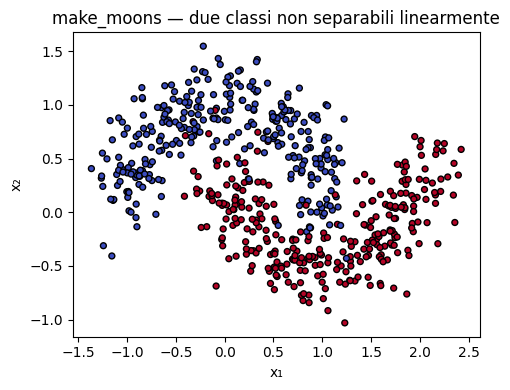

In [ ]:
from sklearn.datasets import make_moons

X_np, y_np = make_moons(n_samples=600, noise=0.20, random_state=SEED)
X2d = torch.tensor(X_np, dtype=torch.float32)
y2d = torch.tensor(y_np, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm', edgecolors='k', s=18)
plt.title('make_moons: due classi non separabili linearmente')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.tight_layout()
plt.show()

### Quattro modelli, quattro confini decisionali

1. **Classificatore lineare**: una **regressione logistica di scikit-learn**: il classificatore
   lineare *standard*.
2. **MLP senza attivazioni**: tre layer lineari uno sopra l'altro (in PyTorch).
3. **MLP + ReLU, pochi layer**: un solo layer nascosto.
4. **MLP + ReLU, tanti layer**: più layer nascosti (stessa larghezza).

### 🔧 Gli oggetti di PyTorch (cosa sono, in breve)

Stiamo per definire i nostri primi modelli: ecco i "mattoni" di PyTorch che useremo oggi. Non
serve padroneggiarli come programmatori ma basta sapere *cosa rappresentano*.

- **Tensore** (`torch.Tensor`): l'oggetto base. Un array n-dimensionale (matematicamente, appunto, un tensore) che
  però può stare su GPU per accelerare i calcoli e tenere traccia dei gradienti, cioè ricordare le operazioni
  subite così che PyTorch possa poi calcolare automaticamente le derivate. Dati, pesi e output sono tutti tensori.
- **`nn.Module`**: la **classe base di ogni rete** (e di ogni suo pezzo). Per definire un modello si
  scrive una classe che *eredita* da `nn.Module`: nel `__init__` si dichiarano i layer (i pezzi che la
  rete contiene), mentre in `forward(x)` si descrive come i dati sono modificati quando passano attraverso la rete.
  Scrivere `model(x)` esegue da solo `forward`. In più, ereditare da `nn.Module` dà gratis utilità comode, come
  raccogliere tutti i pesi allenabili o spostare l'intero modello su GPU con un solo comando.
- **`nn.Linear(in, out)`**: un layer "denso" (o *fully connected*). Prende un vettore di `in` numeri e ne produce
  uno di `out`, calcolando $y = Wx + b$, con pesi $W$ e bias $b$ allenabili. È una trasformazione affine.
- **`nn.Sequential(layer1, layer2, ...)`**: un contenitore che incolla più layer in fila; i dati li
  attraversano nell'ordine dato, l'uscita di uno diventa l'ingresso del successivo. Comodo per costruire reti
  semplici senza dover scrivere a mano una classe con `forward`.
- **Attivazioni** (`nn.ReLU`, `nn.Sigmoid`, …): la **nonlinearità** messa tra i layer (Blocco 4). Senza di esse una
  pila di layer lineari resterebbe equivalente a un singolo layer lineare: sono ciò che permette alla rete di
  imparare relazioni complesse e non solo rette.
- **`nn.Flatten`**: "appiattisce" un tensore a più indici in un vettore unico: per esempio trasforma una immagine
  `1×28×28` in un vettore di `784` numeri (Blocco 3). Serve quando si vuole passare da una struttura a griglia
  (come un'immagine) a un layer denso, che si aspetta un vettore in ingresso.
- **Funzione di costo / *loss*** (`nn.CrossEntropyLoss`): un numero che misura quanto il modello
  sbaglia confrontando le sue previsioni con le risposte giuste (la spieghiamo tra poche celle). Più la loss è
  bassa, meglio sta andando: tutto l'addestramento consiste nel renderla più piccola.
- **Ottimizzatore** (`torch.optim.SGD`, `Adam`): la regola che **aggiorna i pesi** per ridurre la loss, sfruttando
  i gradienti calcolati dai tensori. Decide *in che direzione* e *di quanto* spostare ogni peso a ogni passo.
- **`DataLoader`**: serve i dati a piccoli gruppi (*batch*) durante l'addestramento (Blocco 2). È un iteratore
  efficiente che può anche mescolare i dati a ogni epoca e caricarli in parallelo, così non serve tenere tutto in memoria in una volta sola.

In [ ]:
# 👉 DA FARE: completa __init__ e forward delle 3 reti giocattolo qui sotto
#    (MLPNoActivation, ShallowReLU, DeepReLU).

# ============================================================================
# RICETTA BASE PER SCRIVERE UNA CLASSE PyTorch
#
# Ogni modello in PyTorch e' una CLASSE che eredita da nn.Module e ha SEMPRE la
# stessa ossatura: due metodi, __init__ e forward. Imparate questo schema e
# saprete scrivere qualsiasi rete: lo schema NON cambia, cambiano solo i layer.
#
#   class NomeRete(nn.Module):           # 1) nome a piacere; tra (...) SEMPRE nn.Module
#
#       def __init__(self):              # 2) COSTRUTTORE: gira quando scrivete NomeRete()
#           super().__init__()           #    PRIMA RIGA, OBBLIGATORIA: avvia nn.Module e attiva
#                                        #    il tracciamento dei pesi. Se la dimenticate vi da errore.
#           self.layer = nn.Linear(...)  #    DICHIARATE qui i layer e salvateli in self.<nome>:
#                                        #    solo cio' che sta in self.<...> viene "imparato".
#
#       def forward(self, x):            # 3) IL CALCOLO: dato l'input x, definisce cosa esce.
#           x = self.layer(x)            #    fate passare x attraverso i layer, in ordine...
#           return x                     #    ...e RESTITUITE il risultato (i "logit" grezzi).
#
# ALCUNE REGOLE IMPORTANTI:
#   - forward() NON si chiama a mano: scrivete  model(x)  e PyTorch chiama forward per voi.
#   - Le forme si devono incastrare: uscita di un layer = ingresso del successivo
#     (es. Linear(2, 32) -> Linear(32, 32) -> Linear(32, 2)).
#   - L'ULTIMO layer da' i logit grezzi: NIENTE softmax qui (ci pensa la loss, CrossEntropyLoss).
#   - Le nonlinearita' (nn.ReLU(), ...) vanno TRA i layer lineari: senza, la rete resta lineare.
#   - Scorciatoia: nn.Sequential(...) mette piu' layer in un unico contenitore. Se lo
#     salvate con un nome a scelta, p.es.  self.net = nn.Sequential(nn.Linear(2, 32),
#     nn.ReLU(), nn.Linear(32, 2)),  allora forward diventa una riga:  return self.net(x)
#   - Leggetevi la documentazione su https://pytorch.org/docs/stable/nn.html se avete dubbi.
# ============================================================================


# FORMATO RICHIESTO (per compatibilita' con train_2d e plot_boundary, gia' scritte):
#   input x di forma (N, 2)  ->  forward restituisce i LOGIT di forma (N, 2),
#   cioe' un punteggio grezzo per ciascuna delle 2 classi (NIENTE softmax).

# Tre layer lineari impilati SENZA attivazioni.
class MLPNoActivation(nn.Module):

    def __init__(self, hidden=32):
        super().__init__()
        # TODO: definisci self.net come una rete con TRE layer lineari e NESSUNA attivazione
        #       (2 feature in ingresso, 2 logit in uscita).
        self.net = ...        # <-- completa

    def forward(self, x):
        # TODO: fai passare x attraverso self.net e restituiscine l'output
        ...

# Un solo layer nascosto con ReLU
class ShallowReLU(nn.Module):

    def __init__(self, hidden=16):
        super().__init__()
        # TODO: self.net = un solo layer nascosto seguito da ReLU, poi l'uscita (2 logit).
        self.net = ...        # <-- completa

    def forward(self, x):
        ...                   # TODO

# Cinque layer nascosti con ReLU, impilati (stessa larghezza)
class DeepReLU(nn.Module):

    def __init__(self, hidden=16):
        super().__init__()
        # TODO: self.net = 5 layer nascosti (stessa larghezza), ciascuno seguito da ReLU,
        #       poi l'uscita (2 logit).  (suggerimento: puoi costruire i layer in un ciclo)
        self.net = ...        # <-- completa

    def forward(self, x):
        ...                   # TODO


### Le reti girano? (forward senza addestramento)

Prima di allenarle, controlliamo che le 3 classi siano scritte bene: le usiamo per **classificare i punti così come sono**, con i pesi casuali iniziali. Non saranno brave, ma se le **forme** tornano e ogni punto riceve una predizione, l'implementazione è corretta.

In [ ]:
# Verifica veloce: esegui DOPO aver completato le 3 classi qui sopra.
# Forward SENZA addestramento: con pesi casuali le reti non sono ancora brave (~50%),
# qui controlliamo solo che le FORME tornino e che ogni punto riceva una predizione.
for nome, rete in [('MLPNoActivation', MLPNoActivation()),
                   ('ShallowReLU',     ShallowReLU()),
                   ('DeepReLU',        DeepReLU())]:
    with torch.no_grad():
        logits = rete(X2d)            # (N, 2): un logit per classe, per ognuno dei 600 punti
        pred   = logits.argmax(1)     # classe predetta (0/1) per ogni punto
        acc    = (pred == y2d).float().mean().item()
    print(f'{nome:16s}  logits {tuple(logits.shape)}  ->  acc senza training: {acc:.2f}')

### 🎯 Loss function: come misuriamo e minimizziamo l'errore

Per addestrare un modello serve un **numero** che dica *quanto il modello sta sbagliando*: è la **funzione di
costo** (o *loss function*). Addestrare significa trovare i pesi che **minimizzano** quel numero. Per le reti neurali la tecnica fondamentale è la **discesa del gradiente**,
anche se non è l'unica possibile (vedi e.g. algoritmi genetici).

**Per la regressione** (prevedere un numero continuo) la loss classica è l'**errore quadratico
medio** (*least squares*) : la media di $(\hat{y} - y)^2$. Questo è esattamente ciò che minimizza la
**regressione lineare**, che cerca la retta che rende più piccola la somma dei quadrati degli scarti.
Altre loss per la regressione includono l'**errore assoluto medio** (MAE) e la **Huber loss**.

**Per la classificazione** (il nostro caso: prevedere un valore categorico) non prevediamo un numero ma una
**probabilità per ciascuna classe**. La misura adatta è la **cross-entropy**: quantifica quanto la
distribuzione di probabilità predetta è lontana dalla risposta giusta. Penalizza poco gli errori
"incerti" e **molto** quelli "sicuri e sbagliati" (predire 99% rosso quando era blu).

NOTA: per diversi problemi, la loss ottimale si può prevedere sulla base della maximum likelihood (MLE) della distribuzione dei dati. Per esempio, la regressione lineare con least squares è equivalente a massimizzare la likelihood di una distribuzione normale dei residui. La regressione logistica con cross-entropy è equivalente a massimizzare la likelihood di una distribuzione Bernoulli (questo è il caso di MNIST). Per altri problemi la scelta della loss è più euristica.

NOTA: In PyTorch: `nn.CrossEntropyLoss`. ⚠️ Vuole i **logit grezzi** (non passati per softmax): incorpora lei softmax + log, in modo numericamente stabile.

`train_2d` (qui sotto) fa proprio questo: a ogni passo calcola la cross-entropy, ne calcola il
gradiente (`loss.backward()`) e aggiorna i pesi (`optimizer.step()`).

*(Anche la regressione logistica di scikit-learn, che useremo come modello lineare, minimizza **questa stessa** cross-entropy, lei la chiama log-loss.)*

> 🎲 **Da dove esce la "probabilità"? (la softmax).** L'ultimo layer non produce probabilità ma **logit** grezzi, un punteggio per classe, anche negativi, che **non** sommano a 1. Per leggerli come probabilità si applica la **softmax**, $\text{softmax}(z)_i = e^{z_i} / \sum_j e^{z_j}$: l'esponenziale li rende positivi, la divisione per la somma li normalizza a 1 (il logit più grande → probabilità più alta). Nel grafico, `F.softmax(model(grid), dim=1)[:, 1]` è la probabilità della classe 1 in ogni punto → la **sfumatura di colore**. ⚠️ In **addestramento** non la chiamiamo a mano: `nn.CrossEntropyLoss` la applica al suo interno (per questo le passiamo i logit grezzi); le probabilità non sono "cablate", **emergono dal training**, la cross-entropy spinge verso 1 la probabilità della classe giusta.

Due funzioni: `train_2d` (**da completare**, è il tuo prossimo esercizio) **addestra** il
classificatore minimizzando la cross-entropy (vedi sopra); `plot_boundary` (già pronta)
**disegna** il confine decisionale appreso.

> 🎨 **Come leggere i grafici qui sotto.** Il colore di sfondo è la **probabilità predetta** dal
> modello in ogni punto del piano: **blu** = il modello è sicuro che sia la classe 0, **rosso** =
> sicuro che sia la classe 1. Le **sfumature intermedie** (verso il bianco) sono le zone di
> *incertezza*, dove la probabilità è vicina al 50%. La **linea nera** è il confine a probabilità
> **0.5**, cioè dove il modello "cambia idea". I punti col bordo nero sono i dati veri.

In [ ]:
# ============================================================================
# PROTOTIPO DI TRAINING LOOP IN PyTorch
#
# Addestrare = ripetere tante volte gli stessi passi che fanno SCENDERE la loss.
# Lo schema NON cambia mai (modello, dati o problema diversi: e' sempre questo).
# Prima si preparano due oggetti, poi si entra nel ciclo.
#
#   optimizer = torch.optim.Adam(model.parameters(), lr=...)  # CHI aggiorna i pesi (e con che passo)
#   criterion = nn.CrossEntropyLoss()                         # COME misuriamo l'errore = la loss
#
#   for epoch in range(epochs):              # un'epoca = una passata sui dati
#       optimizer.zero_grad()                # 1) azzera i gradienti del passo precedente
#       outputs = model(inputs)              # 2) forward: dai dati ai logit
#       loss    = criterion(outputs, y)      # 3) calcola la loss (quanto sta sbagliando)
#       loss.backward()                      # 4) backprop: gradienti della loss su tutti i pesi
#       optimizer.step()                     # 5) aggiorna i pesi nella direzione che riduce la loss
#
#   # Per MISURARE soltanto (niente apprendimento), fuori dal ciclo di update:
#   with torch.no_grad():                    # non tracciare i gradienti: piu' veloce, nessun effetto
#       acc = (model(inputs).argmax(1) == y).float().mean().item()
#
# ALCUNE REGOLE IMPORTANTI:
#   - Sono SEMPRE le stesse 5 righe (1->5), in QUEST'ordine.
#   - zero_grad(): PyTorch ACCUMULA i gradienti, senza azzerarli si
#     sommano tra i passi (bug classico = training che non converge).
#   - la loss è un tensore: loss.item() ne estrae il numero Python (per stamparlo o salvarlo).
#   - In valutazione usate  with torch.no_grad():  (o il decoratore @torch.no_grad()).
#   - Qui è "full-batch" (tutti i dati insieme, dataset minuscolo). Con dataset grandi le stesse
#     5 righe vanno DENTRO un  for x, y in loader:  un mini-batch alla volta (lo vedrete dopo).
# ============================================================================


def train_2d(model, X, y, epochs=600, lr=0.05):
    """Addestramento full-batch sul giocattolo 2D (per i modelli PyTorch)."""
    # 👉 DA FARE: addestra `model` su tutti i dati (X, y) per `epochs` passi (vedi PROTOTIPO sopra).
    #    Qui i dati sono piccoli: niente mini-batch, si può passare direttamente X e y.
    #
    #    COME SI MODIFICA `model`: non va ricostruito né riassegnato. L'optimizer, creato su
    #    model.parameters(), aggiorna i pesi di `model` *in-place* a ogni optimizer.step();
    #    quindi l'oggetto `model` ricevuto come argomento esce già addestrato.
    #
    #    COSA RITORNARE: l'accuratezza sul training set, un float fra 0 e 1 (frazione di punti
    #    classificati correttamente). Il modello non si ritorna: è già aggiornato in-place.
    #    La demo la usa per il titolo del grafico (es.  acc = train_2d(...)).
    ...


def torch_prob_fn(model):
    """Trasforma un modello PyTorch in una funzione 'griglia -> probabilita' della classe 1',
    cosi' possiamo disegnarne il confine con plot_boundary (come per i modelli scikit-learn)."""
    def prob(grid_np):
        with torch.no_grad():
            g = torch.tensor(grid_np, dtype=torch.float32)
            return F.softmax(model(g), dim=1)[:, 1].numpy()   # softmax sui logit -> prob. classe 1
    return prob


def plot_boundary(ax, prob_fn, X_np, y_np, title):
    """Disegna il confine decisionale. `prob_fn` e' una funzione che, data una griglia di
    punti (N, 2), restituisce la probabilita' della classe 1 per ciascun punto. Funziona
    uguale per scikit-learn (predict_proba) e per PyTorch (torch_prob_fn)."""
    pad = 0.4
    x_min, x_max = X_np[:, 0].min() - pad, X_np[:, 0].max() + pad
    y_min, y_max = X_np[:, 1].min() - pad, X_np[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]                 # griglia fitta di punti (40000, 2)
    probs = prob_fn(grid).reshape(xx.shape)              # probabilita' della classe 1 in ogni punto
    ax.contourf(xx, yy, probs, levels=20, cmap='coolwarm', alpha=0.7)   # sfondo colorato = probabilita'
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5)  # linea nera = confine a 0.5
    ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='coolwarm',
                edgecolors='k', s=18)      # i punti veri del dataset
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

ValueError: optimizer got an empty parameter list

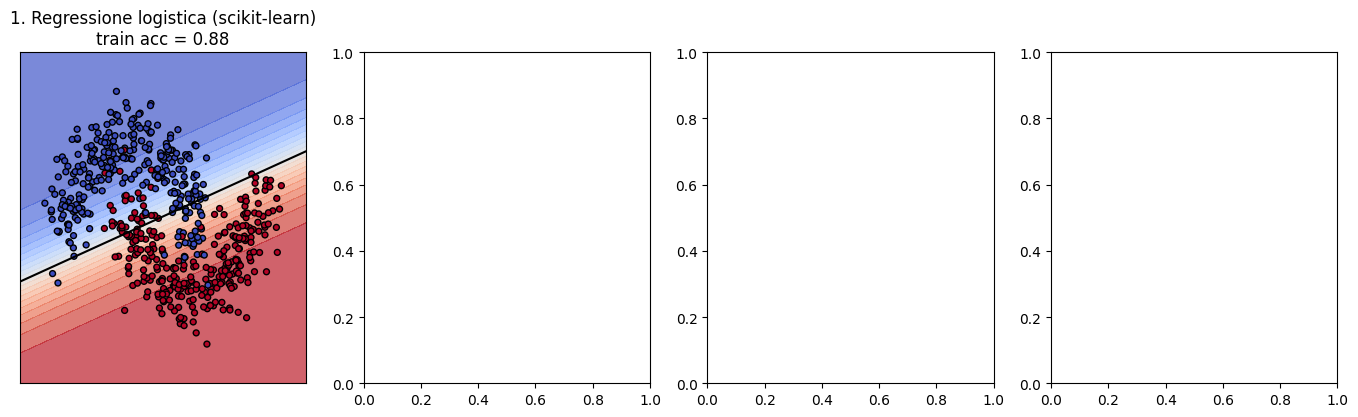

In [ ]:
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))

# --- Modello 1: un classificatore lineare preso da scikit-learn ---
# La regressione logistica e' il classificatore lineare standard: trasparente, niente trucchi.
clf = LogisticRegression()
clf.fit(X_np, y_np)                          # addestra (minimizza la log-loss = cross-entropy)
acc1 = clf.score(X_np, y_np)                 # accuratezza sui dati

# prob1: funzione 'griglia -> probabilita' della classe 1' (modello scikit-learn)
def prob1(grid_np):
    return clf.predict_proba(grid_np)[:, 1]

plot_boundary(axes[0], prob1, X_np, y_np,
              f'1. Regressione logistica (scikit-learn)\ntrain acc = {acc1:.2f}')

# --- Modello 2: MLP PyTorch SENZA attivazioni (tre layer lineari -> resta una retta) ---
torch.manual_seed(SEED)
model2 = MLPNoActivation()
acc2 = train_2d(model2, X2d, y2d)
n2 = sum(p.numel() for p in model2.parameters())     # quanti pesi imparabili
plot_boundary(axes[1], torch_prob_fn(model2), X_np, y_np,
              f'2. MLP senza attivazioni (PyTorch)\n{n2} params · train acc = {acc2:.2f}')

# --- Modello 3: MLP + ReLU con POCHI layer (un hidden) -> confine curvo ma spigoloso ---
torch.manual_seed(SEED)
model3 = ShallowReLU()
acc3 = train_2d(model3, X2d, y2d)
n3 = sum(p.numel() for p in model3.parameters())
plot_boundary(axes[2], torch_prob_fn(model3), X_np, y_np,
              f'3. ReLU pochi layer\n{n3} params · train acc = {acc3:.2f}')

# --- Modello 4: MLP + ReLU con TANTI layer (stessa larghezza) -> confine piu' smooth ---
torch.manual_seed(SEED)
model4 = DeepReLU()
acc4 = train_2d(model4, X2d, y2d)
n4 = sum(p.numel() for p in model4.parameters())
plot_boundary(axes[3], torch_prob_fn(model4), X_np, y_np,
              f'4. ReLU tanti layer · {n4} params\ntrain acc = {acc4:.2f}')

plt.tight_layout()
plt.show()

NOTA: ogni modello classifica in base alla probabilità predetta: > 0.5 → classe 1, altrimenti classe 0. Il confine decisionale è la linea a 0.5.

Guardiamo i quattro confini decisionali:

- Modelli **1** e **2** producono entrambi una **retta**, con accuratezza pressoché
  identica.
- Modelli **3** e **4**, con ReLU, tracciano un confine **curvo** che segue le due lune.
  Con **pochi** layer (3) il confine è spigoloso, fatto di pochi tratti rettilinei; con
  **tanti** layer (4), a parità di larghezza, le "pieghe" si moltiplicano e il confine
  diventa più **smooth**.

L'algebra già anticipava il risultato. La composizione di trasformazioni lineari è ancora lineare:

$$W_3\bigl(W_2(W_1 x + b_1)+b_2\bigr)+b_3 = (W_3 W_2 W_1)\,x + b' = W'x + b'.$$

Quindi i modelli **(1)** e **(2)** computano la stessa famiglia di funzioni (tutte e sole le rette):
il modello (2) ha più parametri ma non più *potere espressivo*. Solo la non linearità di ReLU rompe
questa equivalenza.

**Morale:** la nonlinearità rende una rete neurale qualcosa di più di una regressione
logistica. Inoltre più profondità, a parità di larghezza, dà un confine più ricco e *smooth*.

---
## 2 · I dati: *massaggiare i dati*

Dal dataset giocattolo 2D passiamo ora a un **dataset reale di immagini**, più complesso.
Usiamo **MNIST**: 70 000 immagini 28×28 in scala di grigi di cifre scritte a mano.
Goodfellow lo chiama "the *drosophila* of machine learning".

### Tre passi essenziali
1. **Caricare** il dataset (qui via `torchvision`, che lo scarica una volta).
2. **Normalizzare**: portare i pixel a media ~0 e varianza ~1. Le reti convergono molto
   più velocemente su input ben condizionati, è il "primo massaggio" della slide di Stendardo.
3. **Suddividere** in *train* / *validation* / *test* e creare i `DataLoader` che restituiranno
   minibatch durante l'addestramento.

In [ ]:
DATA_ROOT = Path.home() / '.cache' / 'corsoML_data'
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Media e deviazione standard di MNIST (precalcolate; potete calcolarle anche voi).
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),                      # (H, W) uint8 -> (1, H, W) float in [0, 1]
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),  # standardizza
])

full_train = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_set   = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

# Riserva una parte dei dati di training come validation set.
val_size   = 6_000
train_size = len(full_train) - val_size
train_set, val_set = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH = 128

# I DataLoader servono i dati a mini-batch durante l'addestramento (train mescolato).
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f'train: {len(train_set):>6d}  |  val: {len(val_set):>5d}  |  test: {len(test_set):>5d}')

> 🧊 **Cos'è il "canale"?** `ToTensor` trasforma l'immagine in un tensore di forma `(canali, altezza, larghezza)` = `(1, 28, 28)`: il **canale** è la "profondità" dell'immagine, cioè quanti valori descrivono ogni pixel. MNIST è in **scala di grigi** → **1 canale** (una sola intensità per pixel); una foto **a colori** ne avrebbe **3** (R, G, B). Nei mini-batch davanti si aggiunge la dimensione del batch: `(batch, 1, 28, 28)`. Tenete a mente questo `1`: più avanti le **CNN** trasformeranno l'immagine in **molti canali** (es. 16, 32), uno per ogni filtro che impara a riconoscere un motivo diverso.

### Visualizzare prima di modellare

Regola d'oro: **guardare sempre i dati prima di addestrare.** Un bug nel preprocessing si vede immediatamente a occhio.

In [ ]:
def show_batch(loader, n=16, title='MNIST sample'):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(2, n // 2, figsize=(n // 2 * 1.2, 3))
    for ax, img, lbl in zip(axes.flat, images, labels):
        # de-normalizza solo per la visualizzazione
        img_disp = img.squeeze() * MNIST_STD + MNIST_MEAN
        ax.imshow(img_disp, cmap='gray')
        ax.set_title(int(lbl), fontsize=10)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

### 🎯 Esercizio 2 *(opzionale)*: Distribuzione delle classi

Verificate che il training set sia **bilanciato**: contate quante immagini ci sono per
ciascuna delle 10 classi e disegnate un bar plot. Uno sbilanciamento tra le classi, se non notato, è una causa comune di modelli che sembrano funzionare ma sbagliano sui dati reali.

*Suggerimento:* `train_set.dataset.targets` contiene tutti i target del dataset completo;
gli indici del subset sono in `train_set.indices`.

In [ ]:
# 👉 DA FARE: conta le immagini per ciascuna delle 10 classi e disegnane il bar plot.
# TODO:
#   1) ottieni i target del training set (vedi il suggerimento nella consegna sopra)
#   2) conta quante immagini per ciascuna delle 10 classi
#   3) disegna un bar plot dei conteggi (una barra per classe, 0..9)
targets = ...        # <-- array numpy dei target
counts  = ...        # <-- array numpy di 10 valori (lo usano counts.min()/max() qui sotto)

# TODO: bar plot (plt.figure, plt.bar(range(10), counts), xticks, etichette, titolo, plt.show)
...

print('min:', counts.min(), ' max:', counts.max(),
      ' ratio:', round(counts.max() / counts.min(), 2))


---
## 3 · La prima rete su MNIST: *scegliere il modello e l'obiettivo*

Una **MLP** (multilayer perceptron) è la più semplice rete neurale: una pila di
trasformazioni lineari intervallate da nonlinearità. Per MNIST appiattiamo l'immagine
28×28 in un vettore di 784 numeri, poi applichiamo qualche layer lineare.

$$
h_1 = \sigma(W_1 x + b_1),\quad h_2 = \sigma(W_2 h_1 + b_2),\quad \hat y = \mathrm{softmax}(W_3 h_2 + b_3)
$$

L'**obiettivo** (cross-entropy) misura quanto la distribuzione predetta $\hat y$ è lontana
dal target one-hot $y$. Il segno meno fa sì che la loss diminuisca quando la probabilità
predetta per la classe corretta cresce:

$$\mathcal{L}_\text{CE}(x, y) = -\log \hat y_{[y]}.$$

NOTA: come già visto, `nn.CrossEntropyLoss` vuole i **logit grezzi**, applica softmax e log al suo interno.

In [ ]:
# 👉 DA FARE: completa la classe MLP (i layer in __init__ e il return in forward).
class MLP(nn.Module):
    """Perceptrone multistrato con un solo layer nascosto."""

    def __init__(self, in_features=28 * 28, hidden=128, out=10, activation=nn.ReLU):
        super().__init__()
        # TODO: definisci self.net = MLP con UN layer nascosto.
        #       Appiattisci l'immagine, applica un layer nascosto con attivazione, poi l'uscita.
        #       Usa i parametri della firma (in_features / hidden / out / activation).
        self.net = ...        # <-- completa

    def forward(self, x):
        # forward deve restituire i LOGIT di forma (batch, 10): e' cio' che si aspettano
        # fit()/evaluate() e nn.CrossEntropyLoss (NIENTE softmax qui).
        ...                   # TODO: restituisci self.net(x)


model = MLP().to(DEVICE)
print(model)
print(f'parameters: {sum(p.numel() for p in model.parameters()):,}')


### Il training loop

La struttura generale del training loop è sempre la stessa.

```python
optimizer.zero_grad()          # 1. azzera i gradienti accumulati dal passo precedente
outputs = model(inputs)         # 2. forward pass
loss = criterion(outputs, y)    # 3. calcola la loss
loss.backward()                 # 4. backpropagation: gradienti su tutti i parametri
optimizer.step()                # 5. aggiornamento dei parametri
```

In [ ]:
# 👉 DA FARE: completa il corpo di train_one_epoch, evaluate e fit (vedi PROTOTIPO sopra).
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()                              # modalita' "training" (attiva dropout, ecc.)
    # 👉 DA FARE: completa l'intero giro di addestramento su un'epoca.
    #    - scorri i batch del loader e porta x, y su DEVICE
    #    - per ogni batch fai il passo di training (PROTOTIPO sopra)
    #    - accumula la loss e il numero di predizioni giuste, per poterne fare la media
    #    RESTITUISCI (loss media sull'epoca, accuratezza media): due float.
    ...


@torch.no_grad()                               # in valutazione non servono i gradienti
def evaluate(model, loader, criterion):
    model.eval()                               # modalita' "valutazione" (disattiva dropout)
    # 👉 DA FARE: misura `model` su tutto il loader, senza addestrare (niente backward/step).
    #    - scorri i batch, porta i dati su DEVICE, fai forward e calcola la loss
    #    - accumula loss e predizioni giuste
    #    RESTITUISCI (loss media, accuratezza media): due float.
    ...


def fit(model, train_loader, val_loader, optimizer, criterion, epochs=3, log=True):
    # Ripete per N epoche: addestra su train, misura su validation, registra in `history`.
    # `history`: dict con chiavi 'train_loss','val_loss','train_acc','val_acc', ognuna una
    # lista con 1 valore per epoca. E' il formato che plot_history() si aspetta.
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        # TODO: un giro di training -> (tl, ta);  poi valutazione su val -> (vl, va).
        #       train_one_epoch(...) e evaluate(...) restituiscono ENTRAMBE la coppia (loss, acc).
        tl, ta = ...
        vl, va = ...
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        if log:
            print(f'epoch {epoch:2d}  train loss {tl:.4f} acc {ta:.3f}',
                  f' |  val loss {vl:.4f} acc {va:.3f}')
    return history


### Training demo

Un'**epoca** è un passaggio completo su *tutti* i dati di training (a gruppi di `batch` immagini).

In [ ]:
torch.manual_seed(SEED)
model = MLP().to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

history = fit(model, train_loader, val_loader, optimizer, criterion, epochs=10)

### Le curve di training

`plot_history` (qui sotto) disegna due grafici affiancati: a sinistra `train_loss` e
`val_loss` in funzione dell'epoca, a destra `train_acc` e `val_acc`. È il «dashboard»
che osserverete in ogni esperimento.

In [ ]:
def plot_history(history, title=''):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax_l, ax_a) = plt.subplots(1, 2, figsize=(10, 3))
    ax_l.plot(epochs, history['train_loss'], 'o-', label='train')
    ax_l.plot(epochs, history['val_loss'],   's-', label='val')
    ax_l.set_xlabel('epoch')
    ax_l.set_ylabel('cross-entropy loss')
    ax_l.legend()
    ax_l.grid(alpha=0.3)

    ax_a.plot(epochs, history['train_acc'], 'o-', label='train')
    ax_a.plot(epochs, history['val_acc'],   's-', label='val')
    ax_a.set_xlabel('epoch')
    ax_a.set_ylabel('accuracy')
    ax_a.legend()
    ax_a.grid(alpha=0.3)

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history, title='MLP con SGD')

# Che oggetto e' `history`? Un dizionario con una lista di valori per epoca:
print('history:', {k: f'lista di {len(v)} valori' for k, v in history.items()})

---
## 4 · Le funzioni di attivazione

> 📎 *Collegamento con la teoria:* nelle slide avete visto le attivazioni di **output** (sigmoid,
> softmax, slide 31). Qui parliamo delle attivazioni dei layer **nascosti** e di il fenomeno del
> **vanishing gradient**. È il "perché" dietro la scelta di ReLU,
> che abbiamo già usato (come semplice nonlinearità) nei blocchi 1 e 3.

Senza nonlinearità una rete a $L$ strati lineari è equivalente a un *singolo* strato
lineare: $W_L \cdots W_1 = W'$. La nonlinearità è ciò che distingue una rete neurale da una semplice regressione lineare.

Tre attivazioni storiche, in ordine cronologico:

| Funzione | Formula | Pro | Contro |
|---|---|---|---|
| **Sigmoid** | $\sigma(x) = 1 / (1 + e^{-x})$ | output in $(0,1)$, derivabile ovunque | satura ai bordi → gradiente sparisce |
| **Tanh** | $\tanh(x)$ | centrata in 0, simile a sigmoid | stessa saturazione |
| **ReLU** | $\max(0, x)$ | gradiente costante per $x > 0$, banalmente calcolabile | "dying ReLU" se l'input è sempre negativo |

L'avvento di **ReLU** nel 2010 (Glorot, Bordes & Bengio) ha aperto la strada alle reti
profonde: senza saturazione, il gradiente sopravvive al backprop attraverso decine di layer.

In [ ]:
x = torch.linspace(-5, 5, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

for fn, name in [(torch.sigmoid, 'sigmoid'),
                 (torch.tanh,    'tanh'),
                 (F.relu,        'ReLU')]:
    ax[0].plot(x, fn(x), label=name)
    # derivata via autograd su un tensore foglia nuovo
    x_grad = x.clone().requires_grad_(True)
    dy = torch.autograd.grad(fn(x_grad).sum(), x_grad)[0]
    ax[1].plot(x, dy, label=name)

ax[0].set_title('activation')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].set_title("derivative: note sigmoid/tanh saturation")
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Vanishing gradient: una rete profonda con sigmoid

Quando impiliamo cinque layer con **sigmoid**, il gradiente della loss rispetto
ai parametri del primo layer è il prodotto di cinque derivate $\le 0.25$.
Numericamente diventa zero, la rete non impara più.
Sostituire sigmoid con ReLU risolve il problema con un'unica riga di codice.

In [ ]:
# --- DeepMLP: una MLP profonda la cui attivazione e' un PARAMETRO ----------

class DeepMLP(nn.Module):
    def __init__(self, hidden=128, depth=5, activation=nn.ReLU, out=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28 * 28, hidden), activation()]
        for _ in range(depth - 1):                 # aggiunge depth-1 layer nascosti
            layers += [nn.Linear(hidden, hidden), activation()]
        layers += [nn.Linear(hidden, out)]         # layer finale -> 10 logit (senza attivazione)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


print('DeepMLP ready (5 hidden layers by default).')

### 🎯 Esercizio 4: Sigmoid vs ReLU su una MLP profonda

La classe `DeepMLP` (una MLP a 5 hidden layer) **vi è già data** nella cella sopra: il suo
costruttore accetta l'attivazione come argomento.

Addestrate la `DeepMLP` **due volte**, per poche epoche:
1. con `activation=nn.Sigmoid`,
2. con `activation=nn.ReLU`.

Poi sovrapponete in un unico grafico le due curve di **train loss**.

Con **sigmoid** la loss resta quasi piatta (il gradiente svanisce
attraverso i 5 layer e la rete fatica a imparare); con **ReLU** scende rapidamente.

*Suggerimento:* riusate lo schema del blocco 3, `torch.manual_seed(SEED)`, costruite il
modello con `.to(DEVICE)`, un `optimizer` SGD, e chiamate `fit(...)`. `fit` restituisce un
`history`: la curva che vi serve è `history['train_loss']`.

> ℹ️ Conta la *forma* della curva, sigmoid quasi piatta, ReLU che scende, più che il valore assoluto della loss.

In [ ]:
# 👉 DA FARE: completa train_quick, poi addestra la DeepMLP con Sigmoid e con ReLU
#    e confronta le due curve di train loss.
# DeepMLP e' gia' definita sopra. Qui la addestriamo due volte e confrontiamo.

# --- Shape check: che oggetti maneggia la rete? ---
xb, yb = next(iter(train_loader))
print(f'batch immagini : {tuple(xb.shape)}   (batch, canali, righe, colonne)')
print(f'batch etichette: {tuple(yb.shape)}   (una classe per immagine)')
with torch.no_grad():
    print(f'output (logit) : {tuple(DeepMLP()(xb).shape)}   (batch, 10 classi)')


def train_quick(activation, epochs=10, lr=0.05):
    """Costruisce una DeepMLP con l'attivazione data, la addestra, restituisce history."""
    torch.manual_seed(SEED)
    # TODO: costruisci la DeepMLP con l'attivazione data (su DEVICE), scegli optimizer e loss,
    #       addestrala con fit(...) e RESTITUISCI l'history.
    #       (history = dict con 'train_loss','val_acc',...: sotto si usa h_sig['train_loss'] e h_sig['val_acc'][-1])
    ...

# TODO: addestra due volte usando train_quick, con nn.Sigmoid e con nn.ReLU
h_sig  = ...
h_relu = ...

# TODO: sovrapponi le due curve di train_loss (h_sig['train_loss'] e h_relu['train_loss'])
plt.figure(figsize=(7, 3.5))
...
plt.xlabel('epoch')
plt.ylabel('train loss')
plt.title('5-layer MLP: vanishing gradient with sigmoid')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final val acc, sigmoid: {h_sig['val_acc'][-1]:.3f},  ReLU: {h_relu['val_acc'][-1]:.3f}")


---
## 5 · Ottimizzatori: come vengono aggiornati i pesi?

Tutti gli ottimizzatori che useremo discendono dallo stesso schema base:

$$\theta_{k+1} = \theta_k - \eta\, g_k$$

dove $g_k$ è una stima del gradiente $\nabla_\theta \mathcal{L}$ e $\eta$ è il *learning rate*.
Tre evoluzioni in ordine di sofisticazione crescente:

| Nome | Cosa aggiunge | Idea |
|---|---|---|
| **SGD** | nulla | passo fisso lungo il gradiente del minibatch |
| **SGD + momentum** | $v_{k+1} = \alpha v_k - g_k$ | media esponenziale dei gradienti: "accelera in discesa" |
| **Adam** | momenti del primo e secondo ordine | passo adattivo per ogni parametro |

Adam (Kingma & Ba, 2014) è oggi il default per la maggior parte dei task supervisionati.
Funziona quasi sempre senza tuning del learning rate. Per applicazioni delicate, SGD con
momentum e schedule del learning rate batte ancora Adam in generalization (ResNet, ImageNet).

### Sensibilità al learning rate

Un **learning rate** troppo
piccolo porta a una convergenza lentissima. Troppo grande porta a divergenza o oscillazioni.
La strategia tipica è scegliere il valore più grande che non diverga, poi ridurlo nel tempo.

### 🎯 Esercizio 5 *(opzionale)*: Confronto fra SGD, SGD+momentum e Adam

Sulla stessa MLP base (la classe `MLP` del blocco 3), addestrate per 10 epoche con:

1. `torch.optim.SGD(lr=0.05)`
2. `torch.optim.SGD(lr=0.05, momentum=0.9)`
3. `torch.optim.Adam(lr=0.001)`

Plottate le curve di `train_loss`. Adam tipicamente scende prima, ma SGD+momentum lo
raggiunge in poche epoche in più. Notare che Adam usa un learning rate *molto* più piccolo:
è normale, dovuto alla normalizzazione interna di Adam.

In [ ]:
# 👉 DA FARE: completa make_optimizer, poi addestra la MLP con i 3 ottimizzatori e confronta le curve.
def make_optimizer(name, params):
    # TODO: in base a `name` restituisci l'ottimizzatore richiesto dalla consegna
    #       ('sgd' / 'momentum' / 'adam'; i learning rate sono indicati sopra).
    #       Deve essere un torch.optim.* gia' costruito.
    ...

results = {}
for name in ['sgd', 'momentum', 'adam']:
    torch.manual_seed(SEED)
    model = MLP().to(DEVICE)
    # TODO: crea l'optimizer per questo `name`, addestra con fit(...) per 10 epoche (log=False),
    #       e salva l'history in results[name] (sotto si usa hist['train_loss'] e hist['val_acc'][-1]).
    ...

plt.figure(figsize=(7, 3.5))
for name, hist in results.items():
    plt.plot(hist['train_loss'], 'o-', label=name)
plt.xlabel('epoch')
plt.ylabel('train loss')
plt.title('Optimizer comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for name, hist in results.items():
    print(f"{name:>10s}: final val acc = {hist['val_acc'][-1]:.3f}")


---
## 6 · Overfitting e regolarizzazione

Una rete sufficientemente espressiva può memorizzare il training set perfettamente
(loss → 0) ma generalizzare male: la `val_loss` smette di scendere e ricomincia a crescere.
È **overfitting**.

Tre rimedi standard, in ordine di costo:

1. **Più dati** (data augmentation incluso): sempre il rimedio migliore quando disponibile;
2. **Modelli più piccoli**: meno parametri = meno capacità di memorizzare rumore;
3. **Regolarizzazione**: penalità che scoraggiano configurazioni "barocche" dei pesi. In pratica, si "dissuade" la rete dal memorizzare i dati, spingendola a trovare pattern più semplici e generalizzabili.

Due regolarizzatori semplici che useremo:

- **Weight decay (L2)**: aggiunge $\lambda \|W\|^2 / 2$ alla loss. In Bayes è un *prior*
  Gaussiano sui pesi. In PyTorch è il parametro `weight_decay` dell'ottimizzatore.
- **Dropout** (Srivastava et al., 2014): durante il training, ogni neurone è azzerato con
  probabilità $p$. Forza la rete a non dipendere da un singolo cammino: una specie di
  ensemble "virtuale" all'interno di una sola rete. In PyTorch: `nn.Dropout(p)`.

### Effetto dei regolarizzatori

MNIST è troppo facile per vedere overfitting drammatico. Costruiamo una
versione **rumorosa** del training set: prendiamo 4500 esempi e corrompiamo il **25 %**
delle etichette (le rimpiazziamo con una classe casuale).
Le etichette rumorose creano un conflitto fra
"memorizzare il training set" (bene per `train_acc`, male per `val_acc`) e
"generalizzare alla popolazione vera" (bene per `val_acc`). La regolarizzazione
preme verso la seconda. In MNIST pulito le due strategie quasi coincidono e l'effetto
non si vede.

In [ ]:
from torch.utils.data import TensorDataset

def make_noisy_subset(base, N=4500, noise_rate=0.25, seed=SEED):
    """Prende N campioni da `base`, poi corrompe una frazione `noise_rate` delle etichette."""
    indices = torch.randperm(
        len(base), generator=torch.Generator().manual_seed(seed),
    )[:N]
    images, labels = zip(*(base[i] for i in indices.tolist()))
    X = torch.stack(images)
    y = torch.tensor(labels)
    rng = np.random.default_rng(seed + 1)
    n_corrupt = int(noise_rate * N)
    corrupt_idx = rng.choice(N, size=n_corrupt, replace=False)
    for j in corrupt_idx:
        new = int(rng.integers(0, 10))
        while new == int(y[j]):
            new = int(rng.integers(0, 10))
        y[j] = new
    return TensorDataset(X, y)

noisy_train = make_noisy_subset(train_set, N=4500, noise_rate=0.25)
noisy_loader = DataLoader(noisy_train, batch_size=64, shuffle=True)
print(f'Noisy training set: {len(noisy_train)} samples, 25% corrupted labels')

### Senza regolarizzazione: il modello memorizza il rumore

Prendiamo una rete neurale molto grossa per vedere come overfitta. Una `BigMLP` (due hidden layer da 512 unità, ~670 k parametri) sui 4500 esempi rumorosi,
20 epoche con AdamW.

- `train_acc` cresce monotonicamente verso $\sim 1$ (il modello memorizza anche le etichette sbagliate);
- `val_acc` raggiunge un picco verso epoca 3–5, poi **scende**;
- `val_loss` ha un minimo precoce e poi cresce.

È overfitting.

In [ ]:
class BigMLP(nn.Module):
    def __init__(self, hidden=512, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 10),
        )
    def forward(self, x): return self.net(x)

torch.manual_seed(SEED)
model_overfit = BigMLP(hidden=512, dropout=0.0).to(DEVICE)
opt = torch.optim.AdamW(model_overfit.parameters(), lr=1e-3, weight_decay=0.0)
h_overfit = fit(model_overfit, noisy_loader, val_loader, opt, nn.CrossEntropyLoss(),
                epochs=20, log=False)
plot_history(h_overfit, title='Senza regolarizzazione · 4500 samples, 25% noisy labels')
print(f'final train acc = {h_overfit["train_acc"][-1]:.3f}'
      f'  ·  final val acc = {h_overfit["val_acc"][-1]:.3f}'
      f'  ·  peak val acc = {max(h_overfit["val_acc"]):.3f}')

### 🎯 Esercizio 6: Regolarizzazione

Riaddestrate la stessa `BigMLP` aggiungendo:

1. `dropout=0.5` (passatelo al costruttore),
2. `weight_decay=0.05` passato a `torch.optim.AdamW`.

Per 20 epoche, stesso `noisy_loader`. Il modello regolarizzato:

- *rinuncerà* a memorizzare il rumore (`train_acc` satura più bassa),
- e così *manterrà* un `val_acc` significativamente più alto.

Ci aspettiamo un guadagno netto di accuratezza in validazione.

In [ ]:
# 👉 DA FARE: ricrea la BigMLP REGOLARIZZATA (dropout + weight_decay) e addestrala.
#    Il grafico di confronto qui sotto e' gia' pronto.
# --- Shape check: i dati rumorosi e l'output della rete ---
xb, yb = next(iter(noisy_loader))
print(f'batch (noisy)  : immagini {tuple(xb.shape)}, etichette {tuple(yb.shape)}')
with torch.no_grad():
    print(f'output (logit) : {tuple(BigMLP()(xb).shape)}   (batch, 10 classi)')

torch.manual_seed(SEED)
# TODO: ricrea la BigMLP REGOLARIZZATA come da consegna (dropout + weight_decay) e addestrala
#       20 epoche su noisy_loader con fit(...). Salva l'history in h_reg.
model_reg = ...        # il modello regolarizzato
opt       = ...        # l'ottimizzatore (con weight_decay)
h_reg     = ...        # history di fit(...): sotto si usa h_reg['train_acc'], ['val_acc'], ['val_loss']
plot_history(h_reg, title='Con dropout(0.5) + weight_decay(0.05)')

# Grafico di confronto: curve di accuratezza affiancate, val_loss affiancata
fig, (ax_a, ax_l) = plt.subplots(1, 2, figsize=(12, 3.6))
epochs = range(1, len(h_overfit['train_acc']) + 1)
ax_a.plot(epochs, h_overfit['train_acc'], 'o-',  color='C0', label='train (no reg)')
ax_a.plot(epochs, h_overfit['val_acc'],   's--', color='C0', label='val (no reg)')
ax_a.plot(epochs, h_reg['train_acc'],     'o-',  color='C3', label='train (reg)')
ax_a.plot(epochs, h_reg['val_acc'],       's--', color='C3', label='val (reg)')
ax_a.set_xlabel('epoch')
ax_a.set_ylabel('accuracy')
ax_a.set_title('Accuracy')
ax_a.legend(fontsize=8)
ax_a.grid(alpha=0.3)

ax_l.plot(epochs, h_overfit['val_loss'], 's-', color='C0', label='no reg')
ax_l.plot(epochs, h_reg['val_loss'],     's-', color='C3', label='reg')
ax_l.set_xlabel('epoch')
ax_l.set_ylabel('val loss')
ax_l.set_title('Validation loss')
ax_l.legend()
ax_l.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gain = (h_reg['val_acc'][-1] - h_overfit['val_acc'][-1]) * 100
print(f"No reg : final train = {h_overfit['train_acc'][-1]:.3f}, val = {h_overfit['val_acc'][-1]:.3f}")
print(f"Reg    : final train = {h_reg['train_acc'][-1]:.3f}, val = {h_reg['val_acc'][-1]:.3f}")
print(f'val_acc gain from regularization: {gain:+.1f} percentage points')


---
## 7 · CNN: condivisione di pesi e invarianza per traslazione

Una MLP su immagini è uno spreco: tratta ogni pixel come una feature indipendente e ignora
la struttura spaziale. Un bordo verticale è una feature utile *ovunque* compaia
nell'immagine, ma una MLP deve riapprenderlo per ogni posizione.

Le **CNN** (LeCun et al., 1989) risolvono questo con due idee:

1. **Weight sharing**: lo stesso piccolo filtro (es. 3×3) viene applicato a tutte le
   posizioni dell'immagine. Numero di parametri *indipendente dalla risoluzione*.
2. **Pooling**: riduce la risoluzione e rende le feature "meno locali".

Risultato: meno parametri, miglior generalizzazione, capacità di affrontare immagini
molto più grandi di quelle gestibili da una MLP.

> 🧭 *Un accenno, molto generico.* Questo è un esempio di **bias induttivo**: un'assunzione sul mondo "incorporata" nell'architettura. La CNN *assume* che nelle immagini conti la **località** (i pixel vicini sono correlati) e che un pattern utile in un punto lo sia **ovunque** (invarianza per traslazione).

In [ ]:
class SmallCNN(nn.Module):
    """Una rete in stile LeNet: due blocchi convoluzionali + una testa di classificazione snella."""

    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # 32*7*7 = 1568
            nn.Dropout(dropout),
            nn.Linear(32 * 7 * 7, 32), nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_cnn = SmallCNN().to(DEVICE)
print(model_cnn)
n_cnn = sum(p.numel() for p in model_cnn.parameters())
n_mlp = sum(p.numel() for p in MLP().parameters())
print(f'CNN parameters: {n_cnn:,}')
print(f'MLP parameters: {n_mlp:,}')
print(f'  → CNN has {n_cnn/n_mlp:.2f}x as many parameters as the MLP.')

### 🎯 Esercizio 7: Addestrare la CNN e confrontarla con la MLP

Addestrate `SmallCNN` per 3 epoche su tutto il training set, con Adam (`lr=1e-3`).
Stampate l'accuratezza finale sul **test set** della CNN e quella della MLP del blocco 3.

Dovreste vedere la CNN superare la MLP di un paio di punti percentuali, *pur avendo meno
parametri*.

In [ ]:
# 👉 DA FARE: addestra la CNN e la MLP (stesso setup) e confronta l'accuratezza sul test.
torch.manual_seed(SEED)
model_cnn = SmallCNN().to(DEVICE)

# --- Shape check: come cambia la forma attraverso la CNN ---
xb, _ = next(iter(train_loader))
print(f'input          : {tuple(xb.shape)}   (batch, 1 canale, 28x28)')
with torch.no_grad():
    feat = model_cnn.features(xb.to(DEVICE))
    print(f'dopo le conv   : {tuple(feat.shape)}   (batch, 32 canali, 7x7)')
    print(f'output (logit) : {tuple(model_cnn(xb.to(DEVICE)).shape)}   (batch, 10 classi)')

# TODO: addestra la CNN come da consegna (3 epoche, Adam) con fit(...),
#       poi misura l'accuratezza sul TEST set con evaluate(...).
opt           = ...
h_cnn         = ...        # history di fit(...)
_, test_acc_cnn = ...      # evaluate(...) restituisce (loss, acc): test_acc_cnn e' un float

# Riaddestra la MLP semplice per un confronto equo
torch.manual_seed(SEED)
model_mlp_ref = MLP().to(DEVICE)
# TODO: stessa cosa per la MLP (stesso addestramento); accuratezza test in test_acc_mlp
opt             = ...
_               = ...      # fit(...)
_, test_acc_mlp = ...      # evaluate(...) -> (loss, acc): test_acc_mlp e' un float

print()
print(f'MLP  test accuracy: {test_acc_mlp:.4f}')
print(f'CNN  test accuracy: {test_acc_cnn:.4f}')
print(f"CNN  parameters  : {sum(p.numel() for p in model_cnn.parameters()):,}")
print(f"MLP  parameters  : {sum(p.numel() for p in model_mlp_ref.parameters()):,}")


### 🎯 Esercizio 8 *(opzionale)*: Confusion matrix e cifre sbagliate

Avete un CNN allenato (`model_cnn`). Oltre all'accuratezza globale, guardate quali errori commette:

1. calcolate la **confusion matrix** sul test set (riga = classe vera, colonna = predetta) e
   visualizzatela;
2. mostrate una griglia di ~15 **cifre classificate male**, con etichetta vera e predetta.

È esattamente ciò che fareste su un dataset clinico: non basta l'accuratezza globale, conta
*quali* errori il modello commette (un 4 scambiato per 9 è diverso da un 3 scambiato per 8).

In [ ]:
# 👉 DA FARE: calcola la confusion matrix sul test set e mostra una griglia di cifre sbagliate.
from sklearn.metrics import confusion_matrix


@torch.no_grad()
def collect_predictions(model, loader):
    """Esegue il modello su un loader e restituisce (etichette vere, predette, immagini)."""
    model.eval()
    true_all, pred_all, img_all = [], [], []
    for x, y in loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()
        true_all.append(y)
        pred_all.append(pred)
        img_all.append(x)
    return torch.cat(true_all), torch.cat(pred_all), torch.cat(img_all)


y_true, y_pred, images = collect_predictions(model_cnn, test_loader)

# TODO: calcola la confusion matrix sul test set (sklearn) a partire da y_true e y_pred
cm = ...        # <-- matrice 10x10 (np.ndarray): la usano imshow e cm[i,j]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('CNN: confusion matrix (test set)')
for i in range(10):                      # scrive il conteggio dentro ogni cella
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

# TODO: trova gli indici delle immagini classificate male (dove y_true != y_pred)
wrong = ...        # <-- indici (tensore/array): si usa wrong[:n_show], images[idx]
print(f'{len(wrong)} misclassified out of {len(y_true)} test images '
      f'({100 * len(wrong) / len(y_true):.2f}%)')

n_show = min(15, len(wrong))
fig, axes = plt.subplots(3, 5, figsize=(8, 5))
for ax, idx in zip(axes.flat, wrong[:n_show]):
    img = images[idx].squeeze() * MNIST_STD + MNIST_MEAN    # de-normalizza per la visualizzazione
    ax.imshow(img, cmap='gray')
    ax.set_title(f'true {int(y_true[idx])} / pred {int(y_pred[idx])}', fontsize=8)
    ax.axis('off')
for ax in axes.flat[n_show:]:
    ax.axis('off')
plt.tight_layout()
plt.show()
